<a href="https://colab.research.google.com/github/cyp328/Financial-Modelling/blob/main/Finanical_Modelling_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

excel_file_path = '/content/Start-Financial-Forecast-Model.xlsx'

try:
    # Read all sheets from the Excel file
    xls = pd.ExcelFile(excel_file_path)
    sheet_names = xls.sheet_names
    dfs = {sheet_name: xls.parse(sheet_name) for sheet_name in sheet_names}

    print(f"Successfully loaded Excel file: {excel_file_path}")
    print(f"Sheets found: {sheet_names}")

    # Display the first few rows of each sheet
    for sheet_name, df in dfs.items():
        print(f"\n--- Sheet: {sheet_name} ---")
        display(df.head())
        print(f"Shape of '{sheet_name}': {df.shape}")

except FileNotFoundError:
    print(f"Error: The file '{excel_file_path}' was not found. Please ensure it's uploaded to Colab.")
except Exception as e:
    print(f"An error occurred while reading the Excel file: {e}")

Successfully loaded Excel file: /content/Start-Financial-Forecast-Model.xlsx
Sheets found: ['Forecasting Model']

--- Sheet: Forecasting Model ---


,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,NaN,NaN,NaN,2023,2024,2025,2026,2027,NaN,NaN
1,NaN,Figures in USD,Unit,Year 1,Year 2,Year 3,Year 4,Year 5,NaN,NaN
2,NaN,Income Statement,NaN,NaN,NaN,NaN,NaN,NaN,Scenario,1.0
3,NaN,Revenue,$,119850.0,239700.0,419475.0,629212.5,786515.625,NaN,NaN
4,NaN,Cost of Goods Sold,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Shape of 'Forecasting Model': (79, 10)


Now that we have loaded the data from all sheets, please let me know which specific calculations, charts, or functionalities from this Excel model you'd like to recreate in Python. For example, you might want to:

*   Calculate specific financial metrics (e.g., revenue growth, profit margins).
*   Generate particular reports or summaries.
*   Create specific types of charts (e.g., line charts for trends, bar charts for comparisons).
*   Implement specific forecasting methodologies.

Providing details will help me re-create the exact functionality you need!

## Data Analysis and Visualization

Let's begin by analyzing the financial statements, starting with the `Forecasting Model` sheet to understand the company's performance over time.

### Profit and Loss Statement Analysis

In [ ]:
print("Information about the 'Forecasting Model' sheet:")
display(dfs['Forecasting Model'].info())
print("\nFirst few rows of the 'Forecasting Model' sheet:")
display(dfs['Forecasting Model'].head())

Information about the 'Forecasting Model' sheet:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79 entries, 0 to 78
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  0 non-null      float64
 1   Unnamed: 1  61 non-null     object 
 2   Unnamed: 2  46 non-null     object 
 3   Unnamed: 3  44 non-null     object 
 4   Unnamed: 4  47 non-null     object 
 5   Unnamed: 5  47 non-null     object 
 6   Unnamed: 6  47 non-null     object 
 7   Unnamed: 7  47 non-null     object 
 8   Unnamed: 8  1 non-null      object 
 9   Unnamed: 9  1 non-null      float64
dtypes: float64(2), object(8)
memory usage: 6.3+ KB


None


First few rows of the 'Forecasting Model' sheet:


,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,NaN,NaN,NaN,2023,2024,2025,2026,2027,NaN,NaN
1,NaN,Figures in USD,Unit,Year 1,Year 2,Year 3,Year 4,Year 5,NaN,NaN
2,NaN,Income Statement,NaN,NaN,NaN,NaN,NaN,NaN,Scenario,1.0
3,NaN,Revenue,$,119850.0,239700.0,419475.0,629212.5,786515.625,NaN,NaN
4,NaN,Cost of Goods Sold,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


The `Profit and Loss` statement contains various financial line items. To analyze and visualize these, we first need to clean and prepare the data. This involves identifying the period column (e.g., Year/Month) and converting the financial values to a numeric format, as they might be loaded as objects due to currency symbols or commas.

In [ ]:
df_pl = dfs['Forecasting Model'].copy()

# Find the row containing 'Revenue'
start_data_row_idx = df_pl[df_pl['Unnamed: 1'] == 'Revenue'].index.min()

if pd.isna(start_data_row_idx):
    raise ValueError("Could not find 'Revenue' to determine the start of financial data.")

# Extract years
year_columns_raw = df_pl.iloc[0, 3:]
year_cols = [str(int(y)) for y in year_columns_raw if pd.notna(y)]

# Select columns
last_col_idx = df_pl.shape[1]
data_cols_to_select = ['Unnamed: 1'] + [f'Unnamed: {i}' for i in range(3, last_col_idx)]

df_cleaned = df_pl.loc[start_data_row_idx:, data_cols_to_select].copy()
df_cleaned = df_cleaned.rename(columns={'Unnamed: 1': 'Item'})

# Drop rows where 'Item' is NaN to avoid issues with indexing
df_cleaned = df_cleaned.dropna(subset=['Item'])

# Set 'Item' as index. To fix the TypeError, we ensure the index is unique
# by grouping or dropping duplicates if they exist.
df_cleaned = df_cleaned.groupby('Item').first()

# Match columns to year_cols length
if len(year_cols) != len(df_cleaned.columns):
    df_cleaned = df_cleaned.iloc[:, :len(year_cols)]

df_cleaned.columns = year_cols
df_cleaned = df_cleaned.dropna(how='all')

# Transpose
df_pl_transposed = df_cleaned.T
df_pl_transposed.index.name = 'Period'

# Convert to numeric
for col in df_pl_transposed.columns:
    # Clean strings and convert
    s = df_pl_transposed[col].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False).str.replace('(', '-', regex=False).str.replace(')', '', regex=False).str.strip()
    df_pl_transposed[col] = pd.to_numeric(s, errors='coerce')

print("\nCleaned and Transposed Profit and Loss Data:")
display(df_pl_transposed.head())
display(df_pl_transposed.info())

dfs['Profit and Loss_cleaned'] = df_pl_transposed


Cleaned and Transposed Profit and Loss Data:


Item,Average Order Value,Corporate Tax Rate,Gross Profit,Gross Profit Margin,Manufacturing,Marketing,Number of Orders,Operating Profit,Operating Profit Margin,Order Fulfillment,Order Growth Rate,Other,Profit / (Loss),Revenue,Salaries & Payroll,Tax,Total COGS,Total Operating Expenses,Warehouse Rent
Period,,,,,,,,,,,,,,,,,,,
2023,39.95,0.2,93600.0,0.780976,19500.00,25000,3000.0,-6400.0,-0.053400,6750.000,0.00,5000,-6400.0,119850.000,50000,NaN,26250.000,100000,20000
2024,39.95,0.2,187200.0,0.780976,39000.00,25000,6000.0,87200.0,0.363788,13500.000,1.00,5000,69760.0,239700.000,50000,17440.0,52500.000,100000,20000
2025,39.95,0.2,327600.0,0.780976,68250.00,25000,10500.0,177600.0,0.423386,23625.000,0.75,5000,142080.0,419475.000,100000,35520.0,91875.000,150000,20000
2026,39.95,0.2,491400.0,0.780976,102375.00,25000,15750.0,341400.0,0.542583,35437.500,0.50,5000,273120.0,629212.500,100000,68280.0,137812.500,150000,20000
2027,39.95,0.2,614250.0,0.780976,127968.75,25000,19687.5,464250.0,0.590262,44296.875,0.25,5000,371400.0,786515.625,100000,92850.0,172265.625,150000,20000


<class 'pandas.core.frame.DataFrame'>
Index: 5 entries, 2023 to 2027
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Average Order Value       5 non-null      float64
 1   Corporate Tax Rate        5 non-null      float64
 2   Gross Profit              5 non-null      float64
 3   Gross Profit Margin       5 non-null      float64
 4   Manufacturing             5 non-null      float64
 5   Marketing                 5 non-null      int64  
 6   Number of Orders          5 non-null      float64
 7   Operating Profit          5 non-null      float64
 8   Operating Profit Margin   5 non-null      float64
 9   Order Fulfillment         5 non-null      float64
 10  Order Growth Rate         5 non-null      float64
 11  Other                     5 non-null      int64  
 12  Profit / (Loss)           5 non-null      float64
 13  Revenue                   5 non-null      float64
 14  Salaries & Pa

None

### Visualizing Key Financial Trends

Now that the `Forecasting Model` data is cleaned and in a suitable format, let's visualize the trends of key financial metrics such as Revenue, Gross Profit, and Net Profit over the periods.

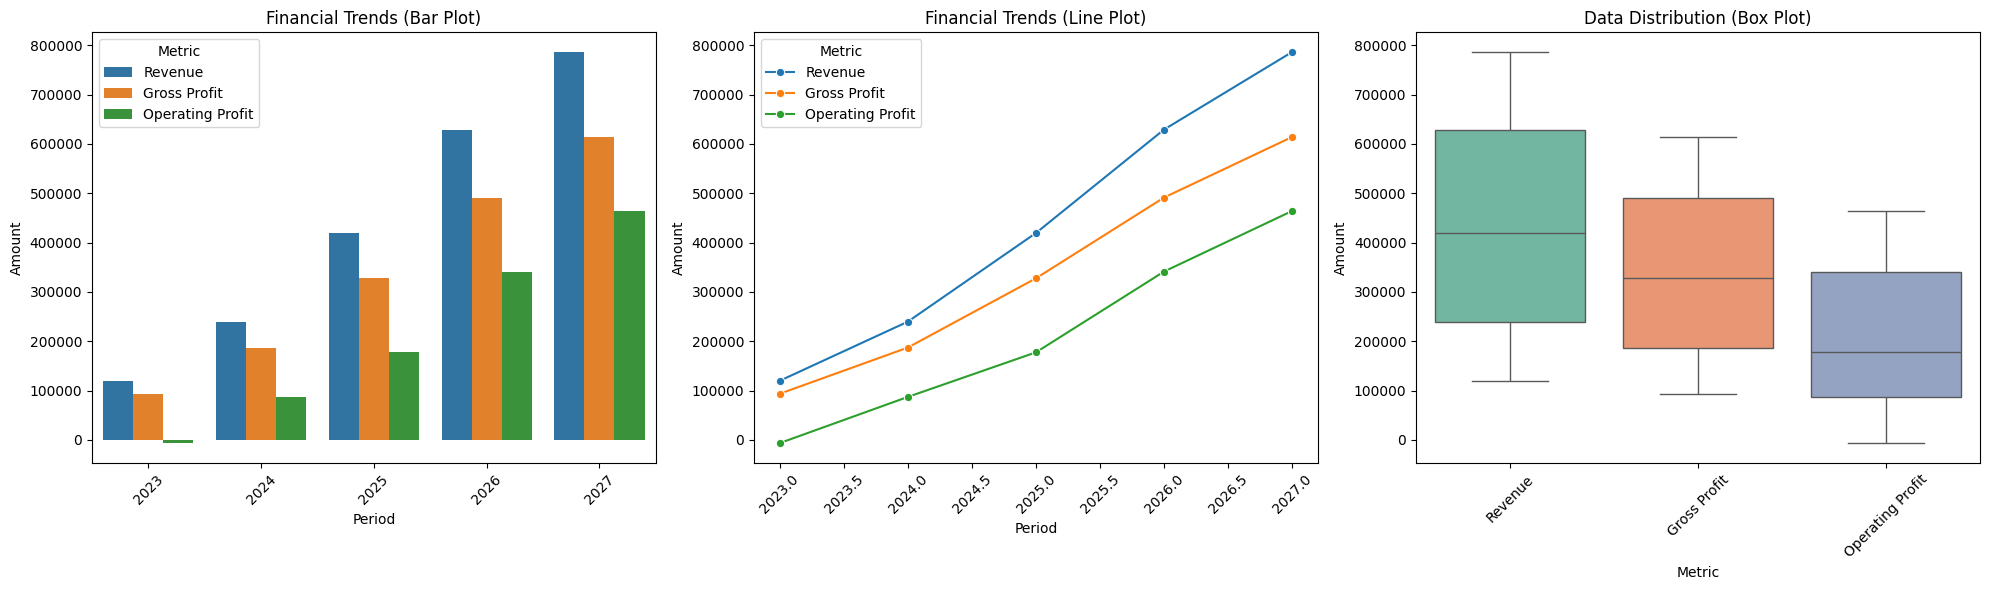

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data
df_pl_plot = dfs['Profit and Loss_cleaned'].reset_index()
try:
    df_pl_plot['Period'] = pd.to_numeric(df_pl_plot['Period'])
    df_pl_plot = df_pl_plot.sort_values(by='Period')
except ValueError:
    pass

# Melt the dataframe for easier plotting with Seaborn (Long Format)
metrics_to_plot = ['Revenue', 'Gross Profit', 'Operating Profit']
df_melted = df_pl_plot.melt(id_vars=['Period'], value_vars=metrics_to_plot, var_name='Metric', value_name='Amount')

# Create a figure with 3 subplots (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Bar Plot
sns.barplot(ax=axes[0], x='Period', y='Amount', hue='Metric', data=df_melted)
axes[0].set_title('Financial Trends (Bar Plot)')
axes[0].tick_params(axis='x', rotation=45)

# 2. Line Plot
sns.lineplot(ax=axes[1], x='Period', y='Amount', hue='Metric', marker='o', data=df_melted)
axes[1].set_title('Financial Trends (Line Plot)')
axes[1].tick_params(axis='x', rotation=45)

# 3. Box Plot (Distribution of metrics across all years)
sns.boxplot(ax=axes[2], x='Metric', y='Amount', hue='Metric', data=df_melted, palette='Set2')
axes[2].set_title('Data Distribution (Box Plot)')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()